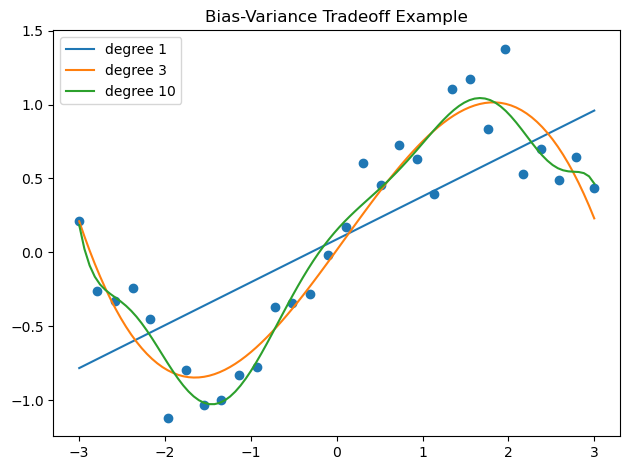

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(0)

X = np.linspace(-3, 3, 30)
y = np.sin(X) + np.random.normal(0, 0.2, size=len(X))

X = X.reshape(-1,1)

degrees = [1, 3, 10]

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    X_test = np.linspace(-3,3,100).reshape(-1,1)
    X_test_poly = poly.transform(X_test)

    y_pred = model.predict(X_test_poly)

    plt.plot(X_test, y_pred, label=f"degree {d}")

plt.scatter(X, y)
plt.legend()
plt.title("Bias-Variance Tradeoff Example")


plt.tight_layout()
plt.savefig("/Figures/bias_variance.pdf", dpi=300, bbox_inches="tight")

plt.show()

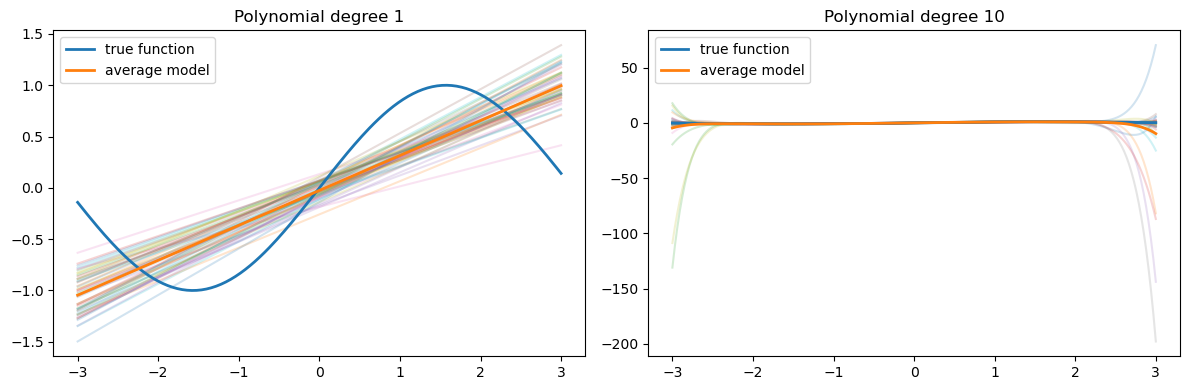

In [37]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

np.random.seed(0)

# True function
def true_function(x):
    return np.sin(x)

# Generate test grid
x_test = np.linspace(-3,3,200)
y_true = true_function(x_test)

x_test = x_test.reshape(-1,1)

# Degrees to compare
degrees = [1, 10]

# Number of datasets
n_datasets = 50

fig, axes = plt.subplots(1,2, figsize=(12,4))

for ax, degree in zip(axes, degrees):

    predictions = []

    for _ in range(n_datasets):

        # Generate training data
        x_train = np.random.uniform(-3,3,30)
        y_train = true_function(x_train) + np.random.normal(0,0.3,30)

        x_train = x_train.reshape(-1,1)

        model = make_pipeline(
            PolynomialFeatures(degree),
            LinearRegression()
        )

        model.fit(x_train, y_train)

        y_pred = model.predict(x_test)
        predictions.append(y_pred)

        ax.plot(x_test, y_pred, alpha=0.2)

    predictions = np.array(predictions)

    # Mean prediction
    mean_prediction = predictions.mean(axis=0)

    ax.plot(x_test, y_true, label="true function", linewidth=2)
    ax.plot(x_test, mean_prediction, label="average model", linewidth=2)

    ax.set_title(f"Polynomial degree {degree}")
    ax.legend()

plt.tight_layout()
plt.show()


/var/folders/j3/yr77zp9x4hv5cydl2hf070rw0000gr/T/ipykernel_57415/4288899210.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


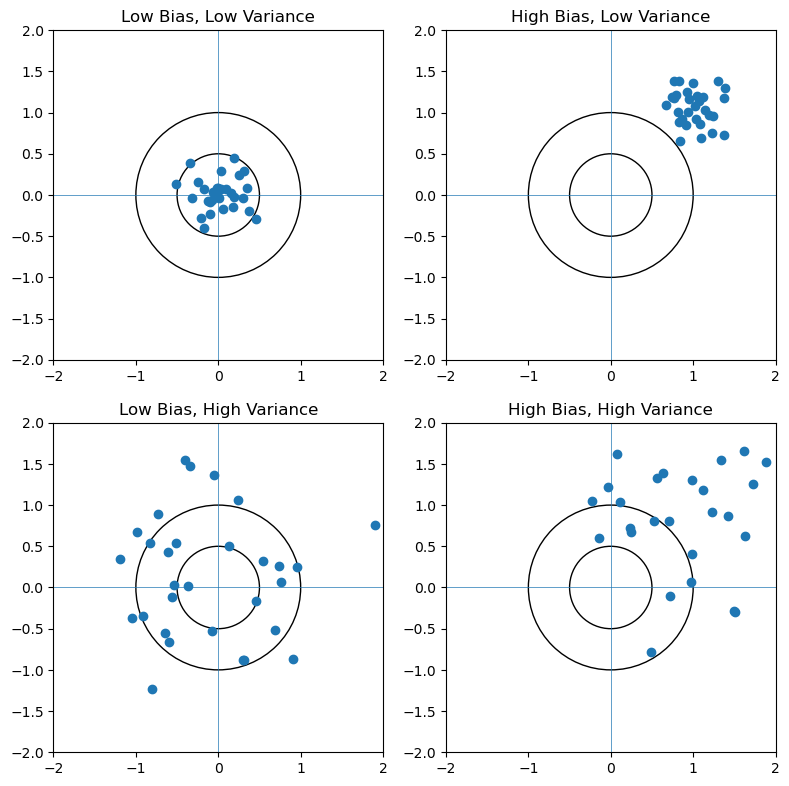

In [42]:


import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

fig, axes = plt.subplots(2,2, figsize=(8,8))

def draw_target(ax):
    circle1 = plt.Circle((0,0),1,color='black',fill=False)
    circle2 = plt.Circle((0,0),0.5,color='black',fill=False)
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.set_aspect('equal')
    ax.axhline(0, linewidth=0.5)
    ax.axvline(0, linewidth=0.5)

# Low bias, low variance
draw_target(axes[0,0])
points = np.random.normal(0,0.2,(30,2))
axes[0,0].scatter(points[:,0],points[:,1])
axes[0,0].set_title("Low Bias, Low Variance")

# High bias, low variance
draw_target(axes[0,1])
points = np.random.normal([1,1],0.2,(30,2))
axes[0,1].scatter(points[:,0],points[:,1])
axes[0,1].set_title("High Bias, Low Variance")

# Low bias, high variance
draw_target(axes[1,0])
points = np.random.normal(0,0.8,(30,2))
axes[1,0].scatter(points[:,0],points[:,1])
axes[1,0].set_title("Low Bias, High Variance")

# High bias, high variance
draw_target(axes[1,1])
points = np.random.normal([1,1],0.8,(30,2))
axes[1,1].scatter(points[:,0],points[:,1])
axes[1,1].set_title("High Bias, High Variance")

plt.tight_layout()



plt.tight_layout()
plt.savefig("/Figures/bullseye.pdf", dpi=300, bbox_inches="tight")
plt.show()


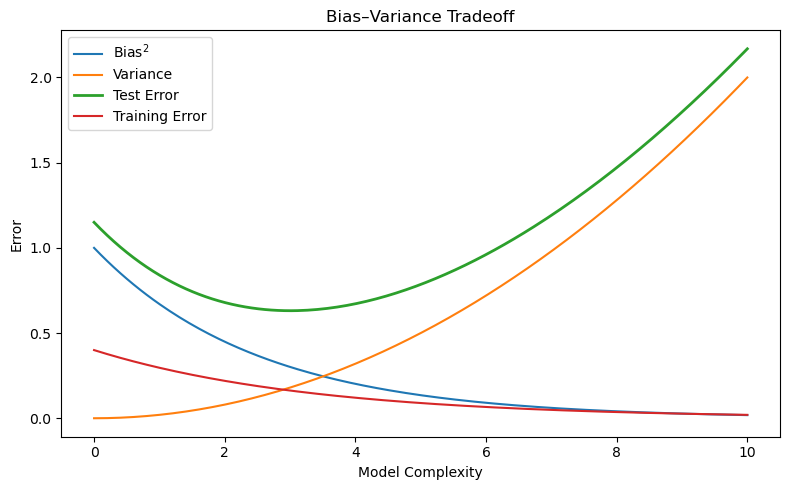

In [51]:

import numpy as np
import matplotlib.pyplot as plt

# Model complexity axis
complexity = np.linspace(0,10,200)

# Simulated curves
bias2 = np.exp(-0.4*complexity)
variance = 0.02 * complexity**2
noise = 0.15

test_error = bias2 + variance + noise
training_error = 0.4*np.exp(-0.3*complexity)

plt.figure(figsize=(8,5))

plt.plot(complexity, bias2, label="Bias$^2$")
plt.plot(complexity, variance, label="Variance")
plt.plot(complexity, test_error, label="Test Error", linewidth=2)
plt.plot(complexity, training_error, label="Training Error")

plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Bias–Variance Tradeoff")

plt.legend()

plt.tight_layout()


plt.savefig("/Figures/bias_variance_tradeoff_curve.pdf", dpi=300, bbox_inches="tight")
plt.show()


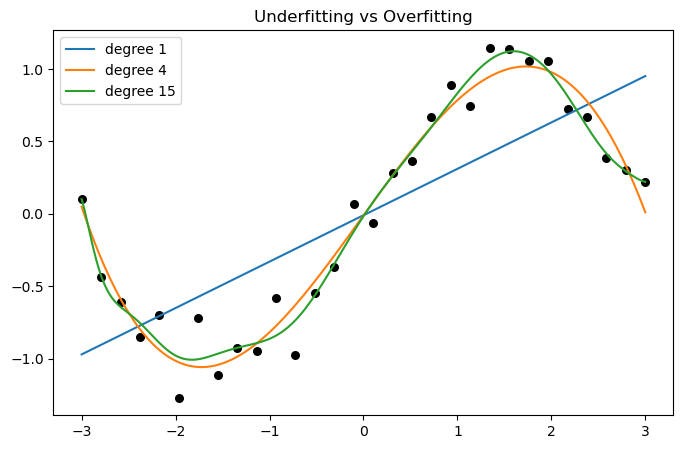

In [52]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

np.random.seed(1)

# Generate synthetic data
X = np.linspace(-3, 3, 30)
y = np.sin(X) + np.random.normal(0, 0.15, size=len(X))

X = X.reshape(-1,1)

# Test points
X_test = np.linspace(-3,3,200).reshape(-1,1)

degrees = [1, 4, 15]

plt.figure(figsize=(8,5))

for d in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree=d),
        LinearRegression()
    )

    model.fit(X, y)
    y_pred = model.predict(X_test)

    plt.plot(X_test, y_pred, label=f"degree {d}")

plt.scatter(X, y, color="black", s=30)
plt.legend()
plt.title("Underfitting vs Overfitting")


plt.savefig("/Figures/underfitting_overfitting.pdf", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/j3/yr77zp9x4hv5cydl2hf070rw0000gr/T/ipykernel_57415/1242748238.py:81: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


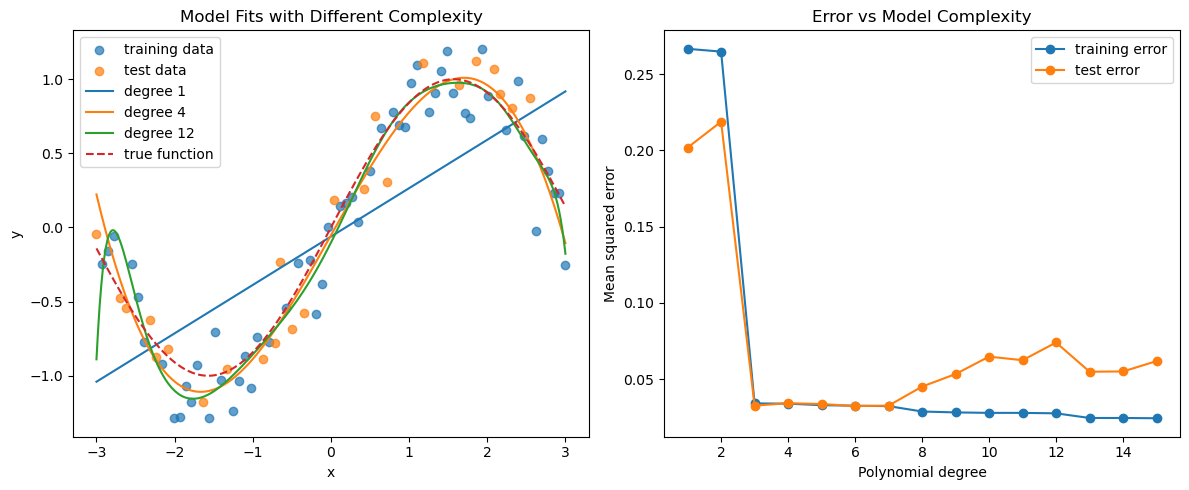

In [31]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# Generate synthetic data
X = np.linspace(-3, 3, 80)
y_true = np.sin(X)
y = y_true + np.random.normal(0, 0.2, size=len(X))

X = X.reshape(-1, 1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Grid for smooth curves
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

# Model degrees for visualization
degrees = [1, 4, 12]

# Degrees for error curve
degrees_full = range(1, 16)
train_errors = []
test_errors = []

for d in degrees_full:
    model = make_pipeline(
        PolynomialFeatures(d),
        LinearRegression()
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ----- Left: fitted models -----
axes[0].scatter(X_train, y_train, label="training data", alpha=0.7)
axes[0].scatter(X_test, y_test, label="test data", alpha=0.7)

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(d),
        LinearRegression()
    )
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)
    axes[0].plot(X_plot, y_plot, label=f"degree {d}")

axes[0].plot(X_plot, np.sin(X_plot), linestyle="--", label="true function")
axes[0].set_title("Model Fits with Different Complexity")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# ----- Right: error vs complexity -----
axes[1].plot(degrees_full, train_errors, marker='o', label="training error")
axes[1].plot(degrees_full, test_errors, marker='o', label="test error")

axes[1].set_title("Error vs Model Complexity")
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("Mean squared error")
axes[1].legend()

plt.tight_layout()


plt.tight_layout()
plt.savefig("/Figures/model_complexity_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.show()




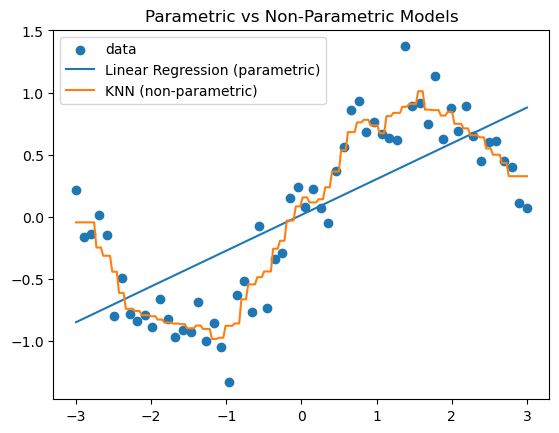

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

np.random.seed(0)

# Generate synthetic data
X = np.linspace(-3,3,60)
y = np.sin(X) + np.random.normal(0,0.2,60)

X = X.reshape(-1,1)

# Fit parametric model
linear_model = LinearRegression()
linear_model.fit(X,y)

# Fit non-parametric model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X,y)

# Prediction grid
X_test = np.linspace(-3,3,200).reshape(-1,1)

y_linear = linear_model.predict(X_test)
y_knn = knn_model.predict(X_test)

plt.scatter(X,y,label="data")
plt.plot(X_test,y_linear,label="Linear Regression (parametric)")
plt.plot(X_test,y_knn,label="KNN (non-parametric)")
plt.legend()
plt.title("Parametric vs Non-Parametric Models")



plt.savefig("/Figures/parametric.pdf", dpi=300, bbox_inches="tight")
plt.show()

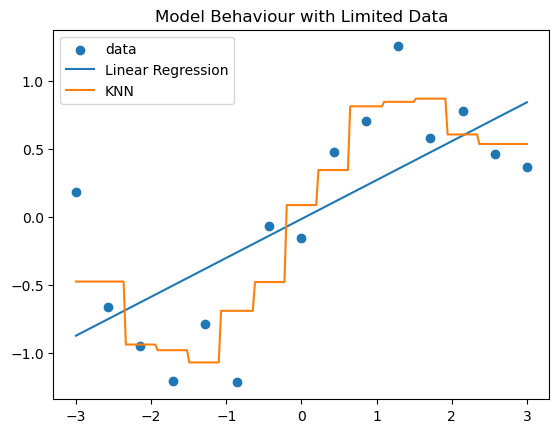

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

np.random.seed(1)

# Small dataset
X = np.linspace(-3,3,15)
y = np.sin(X) + np.random.normal(0,0.2,15)

X = X.reshape(-1,1)

# Models
linear_model = LinearRegression()
knn_model = KNeighborsRegressor(n_neighbors=3)

linear_model.fit(X,y)
knn_model.fit(X,y)

# Prediction grid
X_test = np.linspace(-3,3,200).reshape(-1,1)

y_linear = linear_model.predict(X_test)
y_knn = knn_model.predict(X_test)

plt.scatter(X,y,label="data")
plt.plot(X_test,y_linear,label="Linear Regression")
plt.plot(X_test,y_knn,label="KNN")
plt.legend()
plt.title("Model Behaviour with Limited Data")

plt.savefig("Figures/parametric_vs_nonparametric_small_data.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()

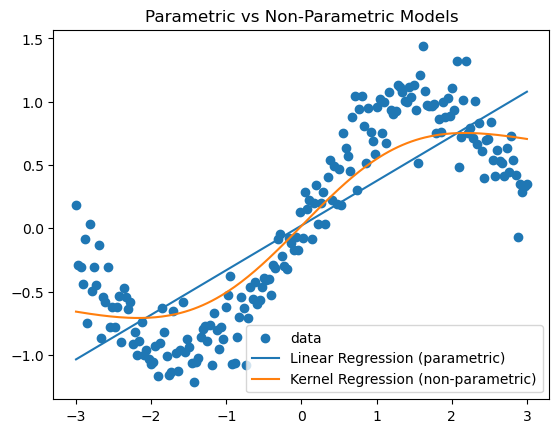

In [66]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import rbf_kernel

np.random.seed(1)

# Small dataset
X = np.linspace(-3,3,20)
y = np.sin(X) + np.random.normal(0,0.2,20)

X = X.reshape(-1,1)

# Fit parametric model
linear_model = LinearRegression()
linear_model.fit(X,y)

# Kernel regression function
def kernel_regression(x_train, y_train, x_test, gamma=1.0):
    K = rbf_kernel(x_test, x_train, gamma=gamma)
    weights = K / K.sum(axis=1, keepdims=True)
    return weights @ y_train

# Prediction grid
X_test = np.linspace(-3,3,200).reshape(-1,1)

y_linear = linear_model.predict(X_test)
y_kernel = kernel_regression(X, y, X_test, gamma=0.5)

plt.scatter(X,y,label="data")
plt.plot(X_test,y_linear,label="Linear Regression (parametric)")
plt.plot(X_test,y_kernel,label="Kernel Regression (non-parametric)")
plt.legend()
plt.title("Parametric vs Non-Parametric Models")

plt.savefig("/Figures/parametric_vs_nonparametric_small_data.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()




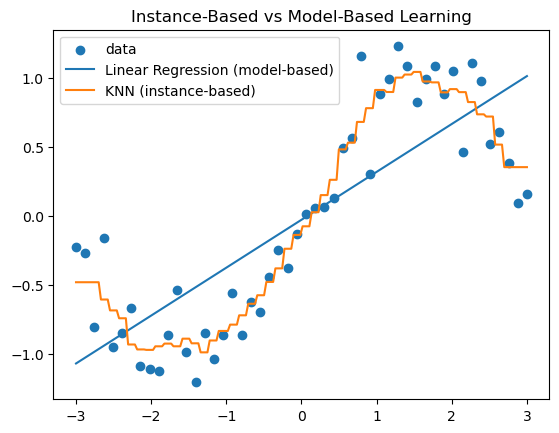

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

np.random.seed(2)

# Generate synthetic data
X = np.linspace(-3,3,50)
y = np.sin(X) + np.random.normal(0,0.2,50)

X = X.reshape(-1,1)

# Model-based learner
linear_model = LinearRegression()
linear_model.fit(X,y)

# Instance-based learner
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X,y)

# Prediction grid
X_test = np.linspace(-3,3,200).reshape(-1,1)

y_linear = linear_model.predict(X_test)
y_knn = knn_model.predict(X_test)

plt.scatter(X,y,label="data")
plt.plot(X_test,y_linear,label="Linear Regression (model-based)")
plt.plot(X_test,y_knn,label="KNN (instance-based)")
plt.legend()
plt.title("Instance-Based vs Model-Based Learning")

plt.savefig("/Figures/instance_vs_model_based_learning.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()

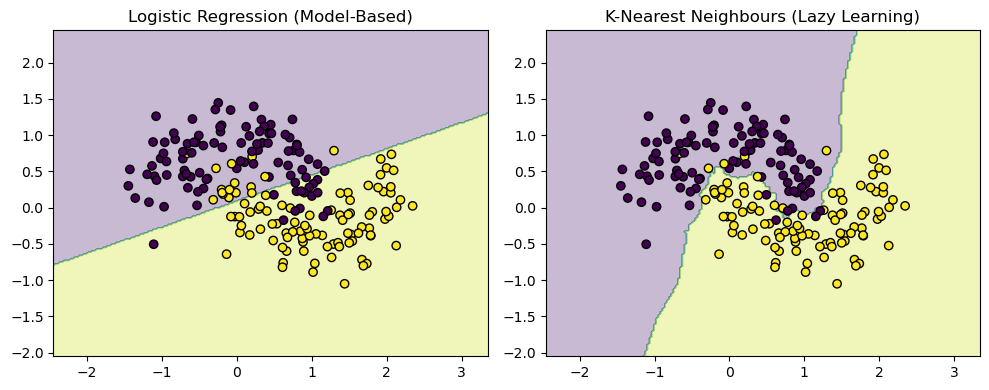

In [70]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Generate synthetic classification dataset
X, y = make_moons(n_samples=200, noise=0.25, random_state=0)

# Train models
log_model = LogisticRegression()
knn_model = KNeighborsClassifier(n_neighbors=5)

log_model.fit(X, y)
knn_model.fit(X, y)

# Create grid for visualising decision boundaries
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z_log = log_model.predict(grid).reshape(xx.shape)
Z_knn = knn_model.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1,2, figsize=(10,4))

# Logistic regression
axes[0].contourf(xx, yy, Z_log, alpha=0.3)
axes[0].scatter(X[:,0], X[:,1], c=y, edgecolor="k")
axes[0].set_title("Logistic Regression (Model-Based)")

# KNN
axes[1].contourf(xx, yy, Z_knn, alpha=0.3)
axes[1].scatter(X[:,0], X[:,1], c=y, edgecolor="k")
axes[1].set_title("K-Nearest Neighbours (Lazy Learning)")

plt.tight_layout()

plt.savefig("/Figures/lazy_vs_model_based_learning.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()




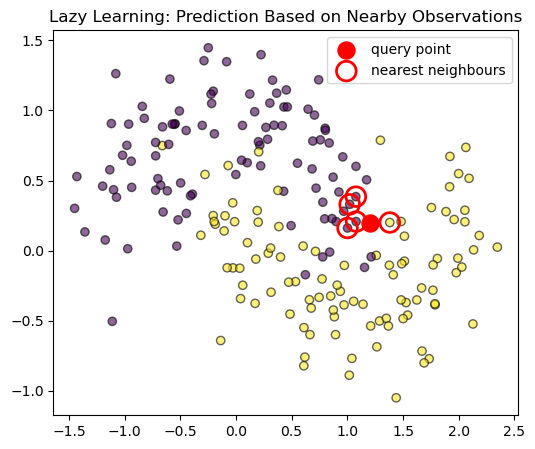

In [72]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Generate dataset
X, y = make_moons(n_samples=200, noise=0.25, random_state=0)

# Train models
log_model = LogisticRegression()
knn_model = KNeighborsClassifier(n_neighbors=5)

log_model.fit(X, y)
knn_model.fit(X, y)

# New query point
x_query = np.array([[1.2, 0.2]])

# Find neighbours used by KNN
distances, indices = knn_model.kneighbors(x_query)
neighbors = X[indices[0]]

# Plot dataset
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, edgecolor="k", alpha=0.6)

# Highlight query point
plt.scatter(x_query[:,0], x_query[:,1],
            color="red", s=150, label="query point")

# Highlight neighbours used for prediction
plt.scatter(neighbors[:,0], neighbors[:,1],
            facecolors="none", edgecolors="red",
            s=200, linewidths=2, label="nearest neighbours")

plt.legend()
plt.title("Lazy Learning: Prediction Based on Nearby Observations")


plt.savefig("/Figures/lazy_learning_neighbours.pdf",
            dpi=300,
            bbox_inches="tight")
plt.show()



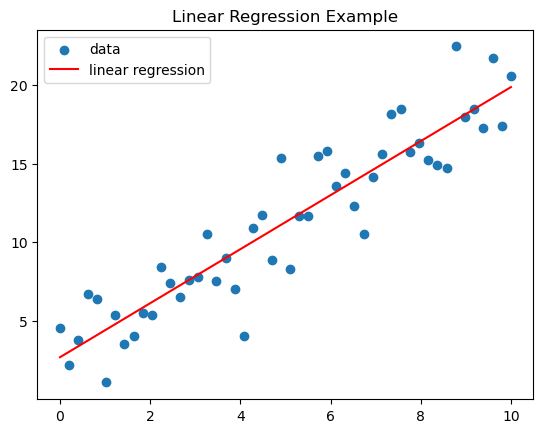

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(0)

# Generate synthetic data
X = np.linspace(0,10,50)
y = 2*X + 1 + np.random.normal(0,2,50)

X = X.reshape(-1,1)

# Fit linear regression model
model = LinearRegression()
model.fit(X,y)

# Predictions
X_test = np.linspace(0,10,100).reshape(-1,1)
y_pred = model.predict(X_test)

# Plot
plt.scatter(X,y,label="data")
plt.plot(X_test,y_pred,color="red",label="linear regression")
plt.legend()
plt.title("Linear Regression Example")

plt.savefig("/Figures/linear_regression_example.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()

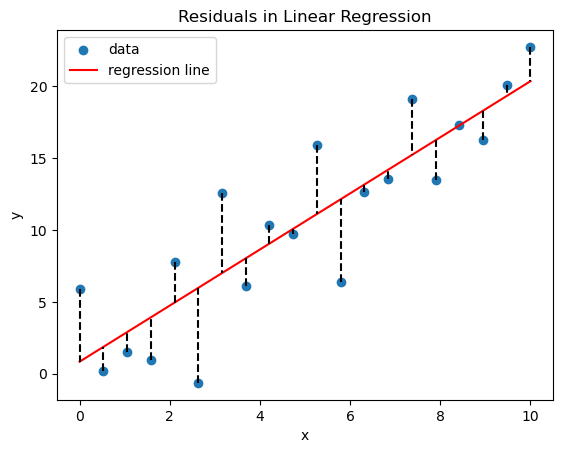

In [74]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(1)

# Generate synthetic data
X = np.linspace(0,10,20)
y = 2*X + 1 + np.random.normal(0,3,20)

X = X.reshape(-1,1)

# Fit regression model
model = LinearRegression()
model.fit(X,y)

# Predictions
X_line = np.linspace(0,10,100).reshape(-1,1)
y_line = model.predict(X_line)

# Plot data
plt.scatter(X,y,label="data")

# Plot regression line
plt.plot(X_line,y_line,color="red",label="regression line")

# Plot residuals
y_pred = model.predict(X)

for i in range(len(X)):
    plt.plot([X[i],X[i]],[y[i],y_pred[i]],
             color="black", linestyle="dashed")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Residuals in Linear Regression")

plt.savefig("Figures/linear_regression_residuals.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()



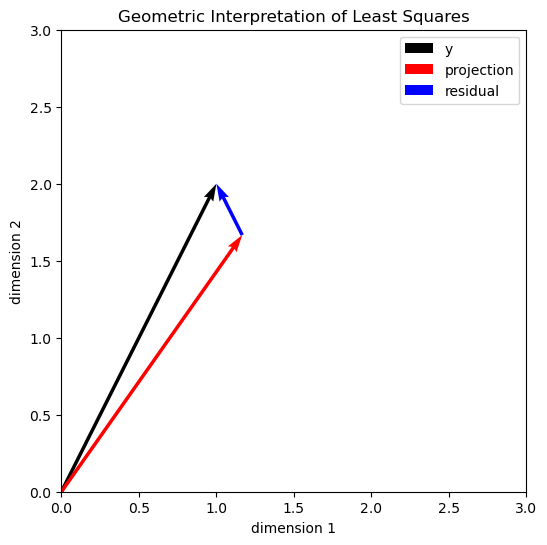

In [75]:

import numpy as np
import matplotlib.pyplot as plt

# Design matrix
X = np.array([
    [1,0],
    [1,1],
    [1,2]
])

# Response vector
y = np.array([1,2,2])

# Compute least squares estimate
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

# Projection
y_hat = X @ beta_hat

# Residual
residual = y - y_hat

plt.figure(figsize=(6,6))

# Plot vectors
plt.quiver(0,0,y[0],y[1],angles='xy',scale_units='xy',scale=1,label="y",color="black")
plt.quiver(0,0,y_hat[0],y_hat[1],angles='xy',scale_units='xy',scale=1,label="projection",color="red")
plt.quiver(y_hat[0],y_hat[1],residual[0],residual[1],
           angles='xy',scale_units='xy',scale=1,label="residual",color="blue")

plt.xlim(0,3)
plt.ylim(0,3)

plt.xlabel("dimension 1")
plt.ylabel("dimension 2")
plt.title("Geometric Interpretation of Least Squares")

plt.legend()

plt.savefig("/Figures/least_squares_projection.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()

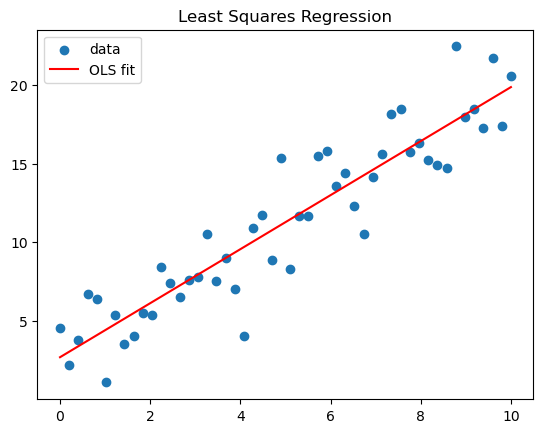

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(0)

# Generate synthetic data
X = np.linspace(0,10,50)
y = 2*X + 1 + np.random.normal(0,2,50)

X = X.reshape(-1,1)

# Fit optimal model
model = LinearRegression()
model.fit(X,y)

# Predictions
y_pred = model.predict(X)

# Compute squared error
mse = mean_squared_error(y, y_pred)

plt.scatter(X,y,label="data")
plt.plot(X,y_pred,color="red",label="OLS fit")

plt.title("Least Squares Regression")
plt.legend()

plt.savefig("/Figures/least_squares_fit.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()

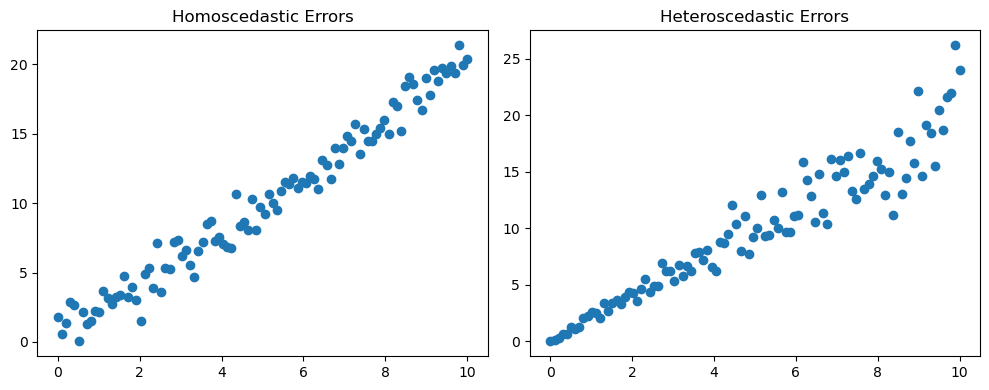

In [78]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

X = np.linspace(0,10,100)

# Homoscedastic errors
y1 = 2*X + np.random.normal(0,1,100)

# Heteroscedastic errors
y2 = 2*X + np.random.normal(0,0.3*X,100)

fig, axes = plt.subplots(1,2, figsize=(10,4))

axes[0].scatter(X,y1)
axes[0].set_title("Homoscedastic Errors")

axes[1].scatter(X,y2)
axes[1].set_title("Heteroscedastic Errors")

plt.tight_layout()

plt.savefig("/Figures/regression_assumptions.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [79]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

np.random.seed(0)

n = 100

# Predictor 1
x1 = np.random.normal(size=n)

# Predictor 2 highly correlated with x1
x2 = x1 + np.random.normal(scale=0.01,size=n)

# Response variable
y = 3*x1 + np.random.normal(size=n)

X = np.column_stack((x1,x2))

model = LinearRegression()
model.fit(X,y)

print("Estimated coefficients:", model.coef_)


Estimated coefficients: [-1.3617683   4.42858466]


In [80]:
import numpy as np
from sklearn.linear_model import LinearRegression

np.random.seed(0)

n = 100

# Generate correlated predictors
x1 = np.random.normal(size=n)
x2 = x1 + np.random.normal(scale=0.01, size=n)

# Response variable
y = 3*x1 + np.random.normal(size=n)

X = np.column_stack((x1, x2))

model = LinearRegression()
model.fit(X, y)

print("Coefficients with correlated predictors:")
print(model.coef_)

# Slightly modify the dataset
x1_new = x1 + np.random.normal(scale=0.05, size=n)
x2_new = x1_new + np.random.normal(scale=0.01, size=n)

X_new = np.column_stack((x1_new, x2_new))

model.fit(X_new, y)

print("Coefficients after small data change:")
print(model.coef_)


Coefficients with correlated predictors:
[-1.3617683   4.42858466]
Coefficients after small data change:
[-7.38687936 10.47023048]


In [81]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(0)

n = 100

x1 = np.random.normal(size=n)
x2 = x1 + np.random.normal(scale=0.01, size=n)
x3 = np.random.normal(size=n)

X = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "x3": x3
})

vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

  variable          VIF
0       x1  9632.651045
1       x2  9633.257188
2       x3     1.007086


In [82]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge

np.random.seed(0)

n = 100

x1 = np.random.normal(size=n)
x2 = x1 + np.random.normal(scale=0.01, size=n)

y = 3*x1 + np.random.normal(size=n)

X = np.column_stack((x1, x2))

# Ordinary least squares
ols = LinearRegression()
ols.fit(X, y)

# Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X, y)

print("OLS coefficients:", ols.coef_)
print("Ridge coefficients:", ridge.coef_)

OLS coefficients: [-1.3617683   4.42858466]
Ridge coefficients: [1.5115071  1.54373856]


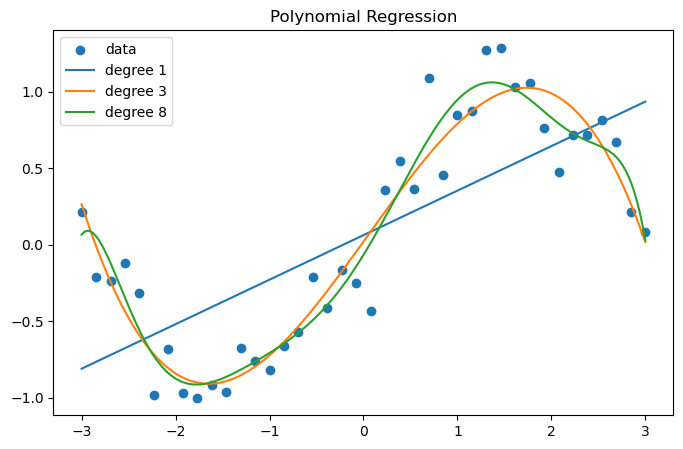

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

np.random.seed(0)

# Generate synthetic data
X = np.linspace(-3,3,40)
y = np.sin(X) + np.random.normal(0,0.2,40)

X = X.reshape(-1,1)

degrees = [1,3,8]

plt.figure(figsize=(8,5))
plt.scatter(X,y,label="data")

X_plot = np.linspace(-3,3,200).reshape(-1,1)

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(d),
        LinearRegression()
    )
    model.fit(X,y)
    y_pred = model.predict(X_plot)
    plt.plot(X_plot,y_pred,label=f"degree {d}")

plt.legend()
plt.title("Polynomial Regression")

plt.savefig("/Figures/polynomial_regression_example.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()

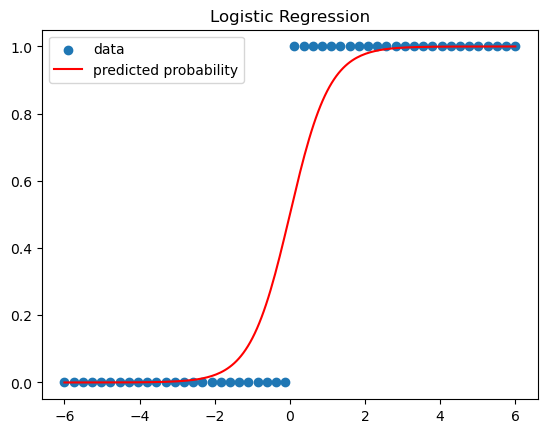

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

np.random.seed(0)

# Generate simple dataset
X = np.linspace(-6,6,50)
y = (X > 0).astype(int)

X = X.reshape(-1,1)

# Fit logistic regression model
model = LogisticRegression()
model.fit(X,y)

# Generate prediction curve
X_plot = np.linspace(-6,6,200).reshape(-1,1)
p = model.predict_proba(X_plot)[:,1]

plt.scatter(X,y,label="data")
plt.plot(X_plot,p,color="red",label="predicted probability")

plt.legend()
plt.title("Logistic Regression")

plt.savefig("/Figures/logistic_regression_curve.pdf",
            dpi=300,
            bbox_inches="tight")

plt.show()

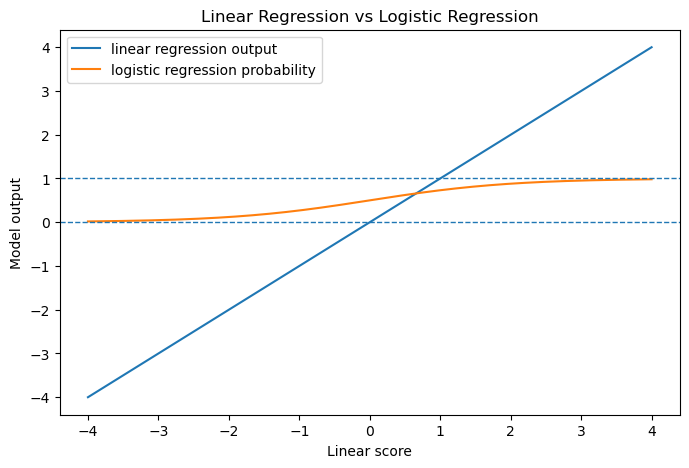

In [87]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-4, 4, 200)
linear_output = z
sigmoid_output = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8,5))
plt.plot(z, linear_output, label="linear regression output")
plt.plot(z, sigmoid_output, label="logistic regression probability")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)
plt.xlabel("Linear score")
plt.ylabel("Model output")
plt.title("Linear Regression vs Logistic Regression")
plt.legend()

plt.savefig("/Figures/linear_vs_logistic_classification.pdf",
            dpi=300,
            bbox_inches="tight")


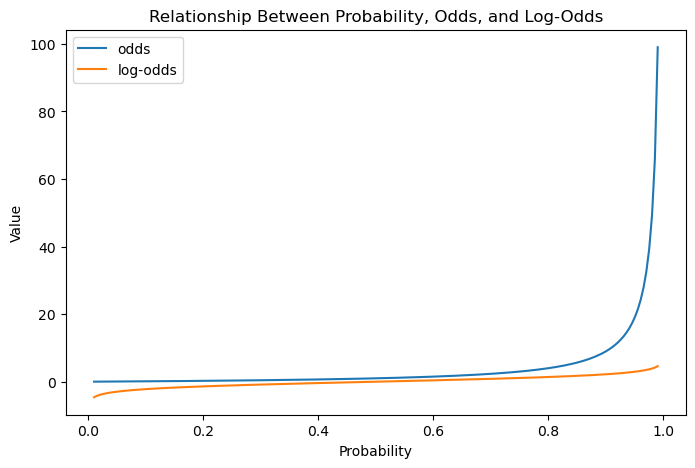

In [88]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.01, 0.99, 200)

odds = p / (1 - p)
log_odds = np.log(odds)

plt.figure(figsize=(8,5))

plt.plot(p, odds, label="odds")
plt.plot(p, log_odds, label="log-odds")

plt.xlabel("Probability")
plt.ylabel("Value")
plt.title("Relationship Between Probability, Odds, and Log-Odds")
plt.legend()

plt.savefig("/Figures/log_odds_plot.pdf",
            dpi=300,
            bbox_inches="tight")

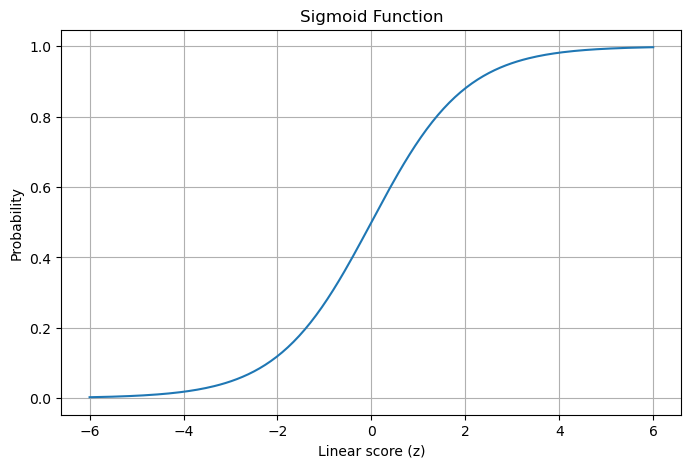

In [91]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-6,6,200)
sigmoid = 1/(1+np.exp(-z))

plt.figure(figsize=(8,5))
plt.plot(z, sigmoid)

plt.xlabel("Linear score (z)")
plt.ylabel("Probability")
plt.title("Sigmoid Function")
plt.grid(True)

plt.savefig("/Figures/sigmoid_function.pdf",
            dpi=300,
            bbox_inches="tight")

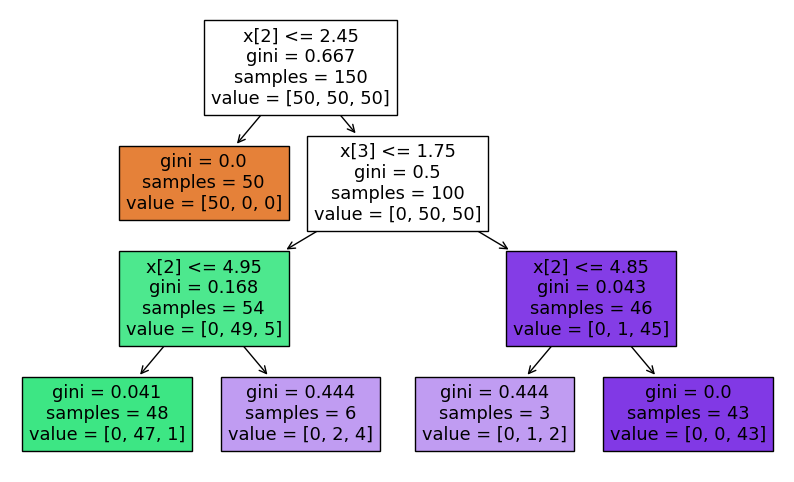

In [94]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

X, y = load_iris(return_X_y=True)

model = DecisionTreeClassifier(max_depth=3)
model.fit(X, y)

plt.figure(figsize=(10,6))
plot_tree(model, filled=True)


plt.savefig("/Figures/decision_tree_example.pdf",
            dpi=300,
            bbox_inches="tight")
plt.show()



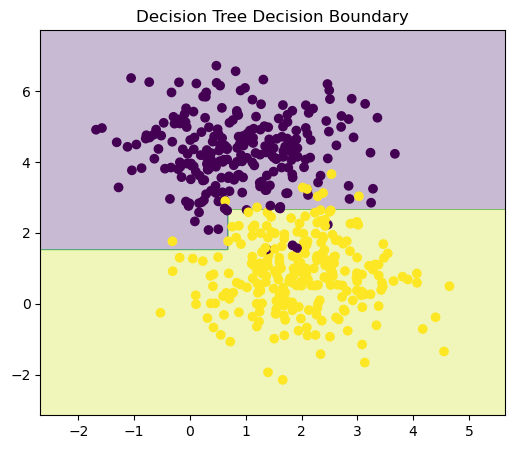

In [100]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier

# generate synthetic data
X, y = make_blobs(n_samples=500, centers=2, random_state=0, cluster_std=1.0)

model = DecisionTreeClassifier(max_depth=3)
model.fit(X, y)

# create grid for decision boundary
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Decision Tree Decision Boundary")

plt.savefig("/Figures/tree_decision_boundary.pdf",
            dpi=300,
            bbox_inches="tight")

In [ ]:
import numpy as np

# class counts from the worked example
class_counts = np.array([7, 3])

# convert to probabilities
p = class_counts / class_counts.sum()

# compute Gini impurity
gini = 1 - np.sum(p**2)

print("Class probabilities:", p)
print("Gini impurity:", gini)

In [101]:
import numpy as np

# class counts from the worked example
class_counts = np.array([7, 3])

# convert to probabilities
p = class_counts / class_counts.sum()

# compute entropy
entropy = -np.sum(p * np.log2(p))

print("Class probabilities:", p)
print("Entropy:", entropy)

Class probabilities: [0.7 0.3]
Entropy: 0.8812908992306927


In [102]:
import numpy as np

def entropy(p):
    return -np.sum(p * np.log2(p))

# parent node
parent = np.array([6,4])
p_parent = parent / parent.sum()
H_parent = entropy(p_parent)

# left node
left = np.array([5,1])
p_left = left / left.sum()
H_left = entropy(p_left)

# right node
right = np.array([1,3])
p_right = right / right.sum()
H_right = entropy(p_right)

n = parent.sum()
weighted_entropy = (left.sum()/n)*H_left + (right.sum()/n)*H_right

information_gain = H_parent - weighted_entropy

print("Parent entropy:", H_parent)
print("Weighted child entropy:", weighted_entropy)
print("Information gain:", information_gain)

Parent entropy: 0.9709505944546686
Weighted child entropy: 0.7145247027726656
Information gain: 0.256425891682003


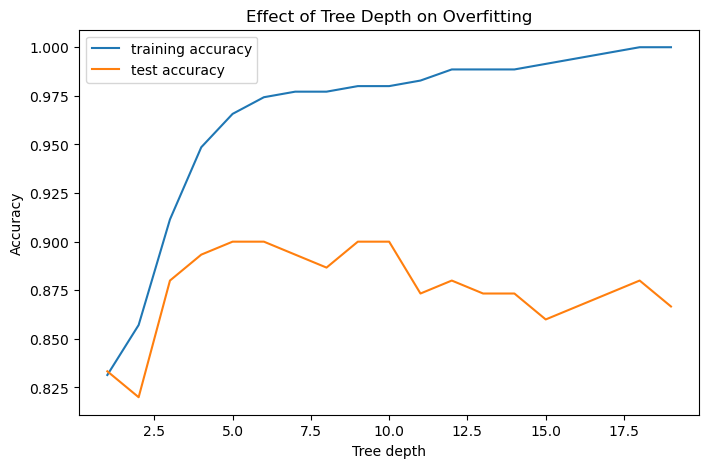

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# generate synthetic classification data
X, y = make_classification(n_samples=500, n_features=5, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10
)

depths = range(1, 20)

train_scores = []
test_scores = []

for d in depths:

    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_scores.append(accuracy_score(y_train, train_pred))
    test_scores.append(accuracy_score(y_test, test_pred))

plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, label="training accuracy")
plt.plot(depths, test_scores, label="test accuracy")

plt.xlabel("Tree depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Overfitting")
plt.legend()

plt.savefig("/Figures/tree_overfitting_depth.pdf",
            dpi=300,
            bbox_inches="tight")

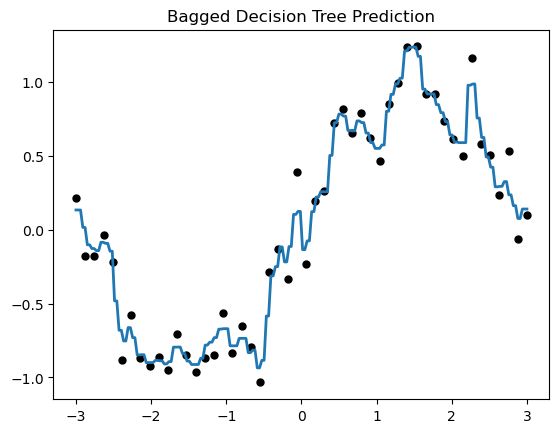

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils import resample

np.random.seed(0)

# generate synthetic data
X = np.linspace(-3,3,50)
y = np.sin(X) + np.random.normal(0,0.2,size=len(X))

X = X.reshape(-1,1)

# train multiple trees on bootstrap samples
n_models = 10
predictions = []

X_test = np.linspace(-3,3,200).reshape(-1,1)

for i in range(n_models):

    X_boot, y_boot = resample(X, y)

    model = DecisionTreeRegressor()
    model.fit(X_boot, y_boot)

    predictions.append(model.predict(X_test))

# average prediction
avg_prediction = np.mean(predictions, axis=0)

plt.scatter(X, y, color="black", s=25)
plt.plot(X_test, avg_prediction, linewidth=2)

plt.title("Bagged Decision Tree Prediction")

plt.savefig("/Figures/bagging_example.pdf",
            dpi=300,
            bbox_inches="tight")

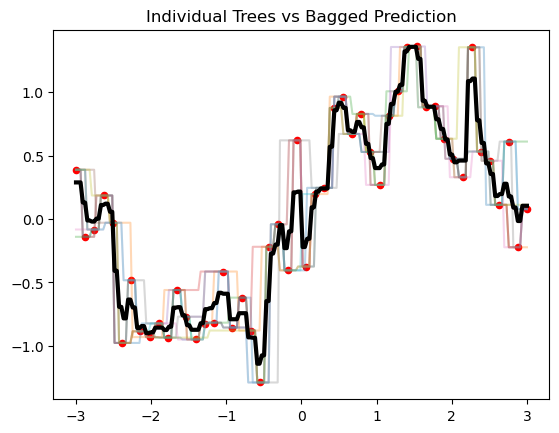

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils import resample

np.random.seed(0)

# generate data
X = np.linspace(-3,3,50)
y = np.sin(X) + np.random.normal(0,0.3,len(X))

X = X.reshape(-1,1)

X_test = np.linspace(-3,3,200).reshape(-1,1)

trees = []
predictions = []

# train several trees on bootstrap samples
for i in range(10):

    X_boot, y_boot = resample(X, y)

    model = DecisionTreeRegressor()
    model.fit(X_boot, y_boot)

    pred = model.predict(X_test)
    predictions.append(pred)

    plt.plot(X_test, pred, alpha=0.3)

# average prediction
avg_pred = np.mean(predictions, axis=0)

plt.plot(X_test, avg_pred, color="black", linewidth=3)
plt.scatter(X, y, color="red", s=20)

plt.title("Individual Trees vs Bagged Prediction")

plt.savefig("/Figures/bagging_variance_reduction.pdf",
            dpi=300,
            bbox_inches="tight")

In [108]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# synthetic dataset representing house features
np.random.seed(0)

X = np.random.rand(200,5)
y = (
    200000
    + 50000*X[:,0]
    + 80000*X[:,1]
    - 30000*X[:,2]
    + np.random.normal(0,10000,200)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

model = RandomForestRegressor(
    n_estimators=100,
    max_features=2,
    random_state=0
)

model.fit(X_train, y_train)

prediction = model.predict(X_test[:5])

print("Predictions:", prediction)

Predictions: [263685.6948651  288768.77880267 239785.6370379  240233.274295
 254519.57000034]


In [109]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(0)

# synthetic dataset with several features
X = np.random.rand(300,5)

# target similar to the worked example (house price style)
y = (
    200000
    + 60000*X[:,0]
    + 50000*X[:,1]
    - 40000*X[:,2]
    + np.random.normal(0,10000,300)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

model = RandomForestRegressor(
    n_estimators=50,
    max_features=2,
    random_state=0
)

model.fit(X_train, y_train)
predictions = model.predict(X_test[:5])

print("Predictions:", predictions)

Predictions: [200395.78804787 220352.74590262 203129.47014609 262116.72468796
 249610.06468798]


In [ ]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# generate dataset
X, y = make_regression(n_samples=500, n_features=10, noise=20, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# single tree
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

# bagging ensemble
ensemble = BaggingRegressor(
    base_estimator=DecisionTreeRegressor(),
    n_estimators=50,
    random_state=0
)

ensemble.fit(X_train, y_train)
ens_pred = ensemble.predict(X_test)

print("Single tree MSE:", mean_squared_error(y_test, tree_pred))
print("Ensemble MSE:", mean_squared_error(y_test, ens_pred))


In [1]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# generate synthetic regression data
X, y = make_regression(n_samples=500, n_features=10, noise=20, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Mean squared error:", mean_squared_error(y_test, pred))


Mean squared error: 2718.3836754127005


In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# generate synthetic regression data
X, y = make_regression(n_samples=500, n_features=10, noise=25, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# model with few boosting iterations
model_small = GradientBoostingRegressor(n_estimators=10, random_state=0)
model_small.fit(X_train, y_train)

# model with more boosting iterations
model_large = GradientBoostingRegressor(n_estimators=100, random_state=0)
model_large.fit(X_train, y_train)

pred_small = model_small.predict(X_test)
pred_large = model_large.predict(X_test)

print("MSE with 10 trees:", mean_squared_error(y_test, pred_small))
print("MSE with 100 trees:", mean_squared_error(y_test, pred_large))


MSE with 10 trees: 10960.919946742968
MSE with 100 trees: 2973.000819213786


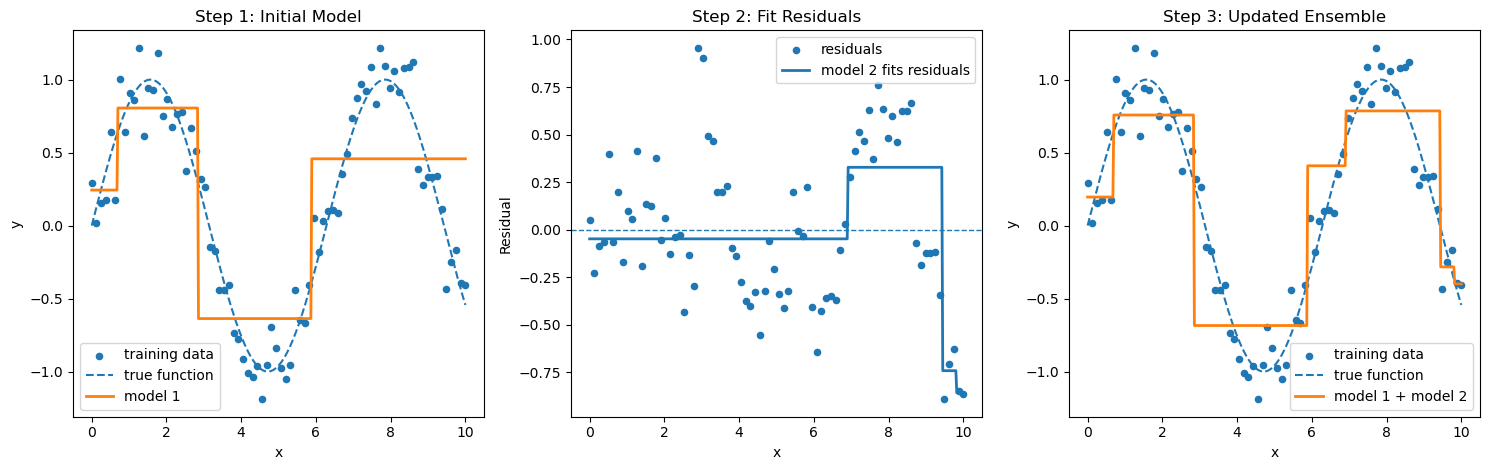

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# --------------------------------------------------
# Synthetic data
# --------------------------------------------------
np.random.seed(1)

X = np.linspace(0, 10, 80).reshape(-1, 1)
y_true = np.sin(X).ravel()
y = y_true + np.random.normal(0, 0.18, size=len(X))

X_plot = np.linspace(0, 10, 400).reshape(-1, 1)
y_plot_true = np.sin(X_plot).ravel()

# --------------------------------------------------
# Stage 1: first weak learner
# --------------------------------------------------
tree1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree1.fit(X, y)
pred1 = tree1.predict(X)
pred1_plot = tree1.predict(X_plot)

# --------------------------------------------------
# Stage 2: fit residuals of first learner
# --------------------------------------------------
residual1 = y - pred1

tree2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree2.fit(X, residual1)
pred2 = tree2.predict(X)
pred2_plot = tree2.predict(X_plot)

# --------------------------------------------------
# Stage 3: combined model
# --------------------------------------------------
final_pred = pred1 + pred2
final_pred_plot = pred1_plot + pred2_plot

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# Panel 1: first model
axes[0].scatter(X, y, s=20, label="training data")
axes[0].plot(X_plot, y_plot_true, linestyle="--", label="true function")
axes[0].plot(X_plot, pred1_plot, linewidth=2, label="model 1")
axes[0].set_title("Step 1: Initial Model")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Panel 2: residuals and residual model
axes[1].scatter(X, residual1, s=20, label="residuals")
axes[1].plot(X_plot, pred2_plot, linewidth=2, label="model 2 fits residuals")
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_title("Step 2: Fit Residuals")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Residual")
axes[1].legend()

# Panel 3: final combined model
axes[2].scatter(X, y, s=20, label="training data")
axes[2].plot(X_plot, y_plot_true, linestyle="--", label="true function")
axes[2].plot(X_plot, final_pred_plot, linewidth=2, label="model 1 + model 2")
axes[2].set_title("Step 3: Updated Ensemble")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].legend()

plt.tight_layout()

plt.savefig(
    "/Figures/gradient_boosting_residuals.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [6]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# generate synthetic classification data
X, y = make_classification(n_samples=500, n_features=10, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# simple neural network
model = MLPClassifier(
    hidden_layer_sizes=(20,10),
    max_iter=1000,
    random_state=0
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))


Accuracy: 0.8133333333333334


/Users/wa22abb/miniconda3/envs/mlp_test/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


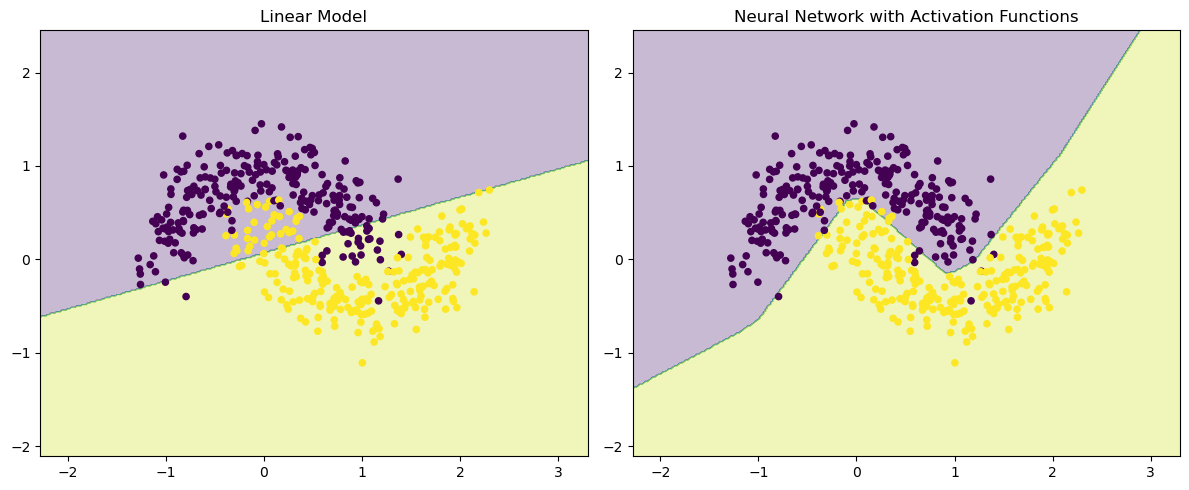

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Generate nonlinear dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Linear model
linear_model = LogisticRegression()
linear_model.fit(X_train, y_train)

# Neural network
nn_model = MLPClassifier(
    hidden_layer_sizes=(10,10),
    max_iter=2000,
    random_state=0
)
nn_model.fit(X_train, y_train)

# Create grid
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z_linear = linear_model.predict(grid).reshape(xx.shape)
Z_nn = nn_model.predict(grid).reshape(xx.shape)

# Plot
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].contourf(xx, yy, Z_linear, alpha=0.3)
axes[0].scatter(X[:,0], X[:,1], c=y, s=20)
axes[0].set_title("Linear Model")

axes[1].contourf(xx, yy, Z_nn, alpha=0.3)
axes[1].scatter(X[:,0], X[:,1], c=y, s=20)
axes[1].set_title("Neural Network with Activation Functions")

plt.tight_layout()

plt.savefig(
"/Figures/activation_function_decision_boundary.pdf",
dpi=300,
bbox_inches="tight"
)

plt.show()

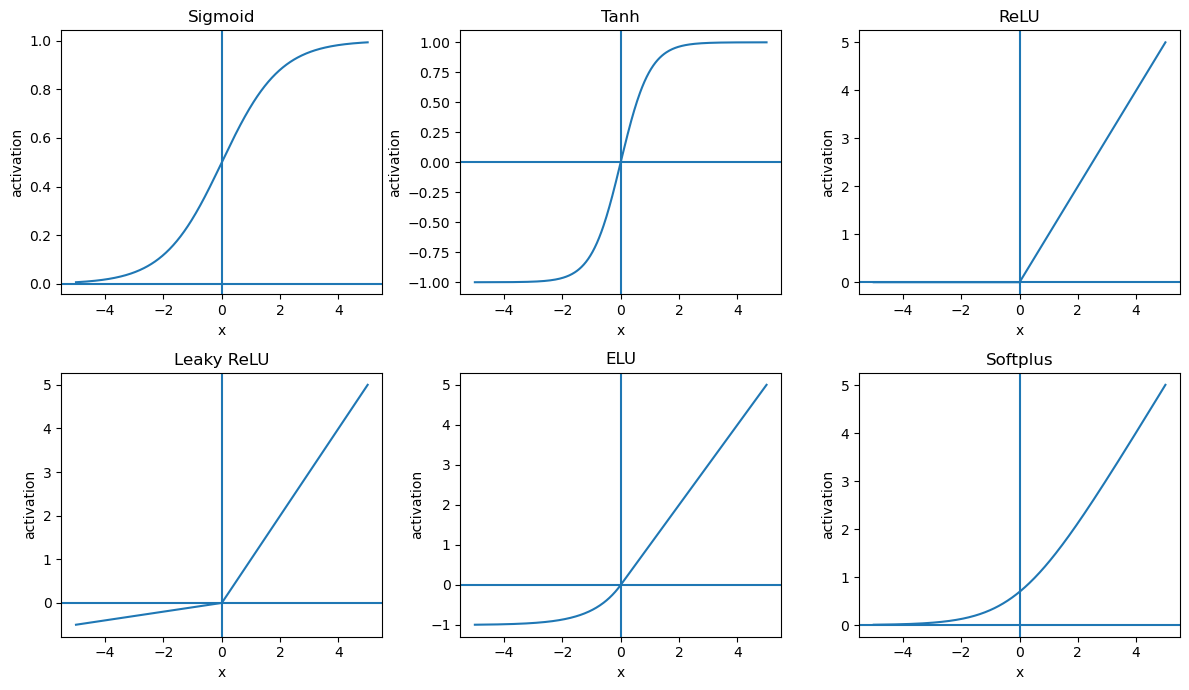

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-5, 5, 400)

# Activation functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.1 * x)
elu = np.where(x > 0, x, np.exp(x) - 1)
softplus = np.log(1 + np.exp(x))

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12,7))

axes[0,0].plot(x, sigmoid)
axes[0,0].set_title("Sigmoid")

axes[0,1].plot(x, tanh)
axes[0,1].set_title("Tanh")

axes[0,2].plot(x, relu)
axes[0,2].set_title("ReLU")

axes[1,0].plot(x, leaky_relu)
axes[1,0].set_title("Leaky ReLU")

axes[1,1].plot(x, elu)
axes[1,1].set_title("ELU")

axes[1,2].plot(x, softplus)
axes[1,2].set_title("Softplus")

for ax in axes.flat:
    ax.axhline(0)
    ax.axvline(0)
    ax.set_xlabel("x")
    ax.set_ylabel("activation")

plt.tight_layout()

plt.savefig(
"/Figures/activation_functions.pdf",
dpi=300,
bbox_inches="tight"
)

plt.show()

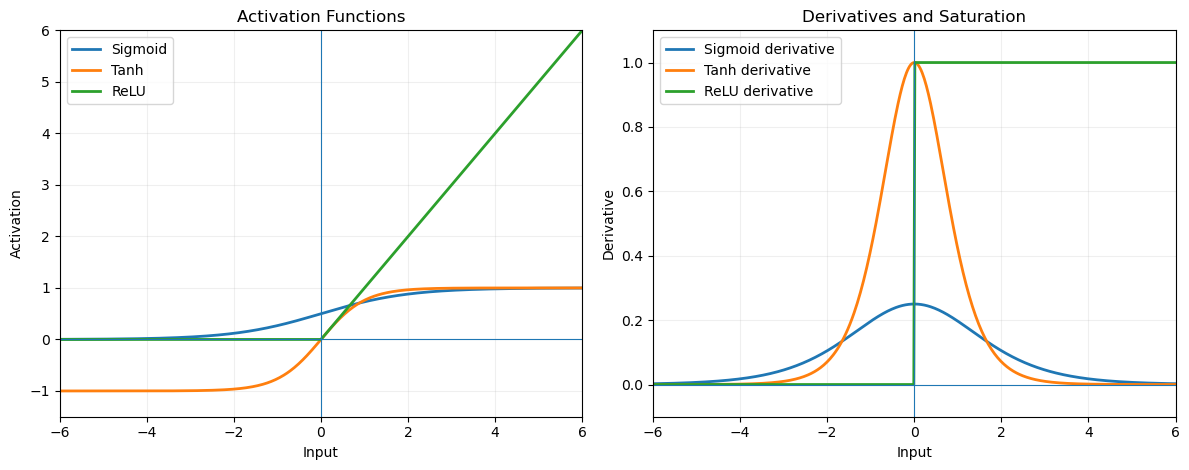

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Input range
# --------------------------------------------------
x = np.linspace(-6, 6, 500)

# --------------------------------------------------
# Activation functions
# --------------------------------------------------
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

# Derivatives
sigmoid_grad = sigmoid * (1 - sigmoid)
tanh_grad = 1 - tanh**2
relu_grad = np.where(x > 0, 1, 0)

# --------------------------------------------------
# Plot activation functions
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

axes[0].plot(x, sigmoid, linewidth=2, label="Sigmoid")
axes[0].plot(x, tanh, linewidth=2, label="Tanh")
axes[0].plot(x, relu, linewidth=2, label="ReLU")

axes[0].axhline(0, linewidth=0.8)
axes[0].axvline(0, linewidth=0.8)
axes[0].set_title("Activation Functions", fontsize=12)
axes[0].set_xlabel("Input")
axes[0].set_ylabel("Activation")
axes[0].set_xlim(-6, 6)
axes[0].set_ylim(-1.5, 6)
axes[0].grid(alpha=0.2)
axes[0].legend()

# --------------------------------------------------
# Plot derivatives
# --------------------------------------------------
axes[1].plot(x, sigmoid_grad, linewidth=2, label="Sigmoid derivative")
axes[1].plot(x, tanh_grad, linewidth=2, label="Tanh derivative")
axes[1].plot(x, relu_grad, linewidth=2, label="ReLU derivative")

axes[1].axhline(0, linewidth=0.8)
axes[1].axvline(0, linewidth=0.8)
axes[1].set_title("Derivatives and Saturation", fontsize=12)
axes[1].set_xlabel("Input")
axes[1].set_ylabel("Derivative")
axes[1].set_xlim(-6, 6)
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "/Figures/activation_saturation.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Logits: [2.  1.  0.1]
Softmax probabilities: [0.65900114 0.24243297 0.09856589]
Sum of probabilities: 1.0


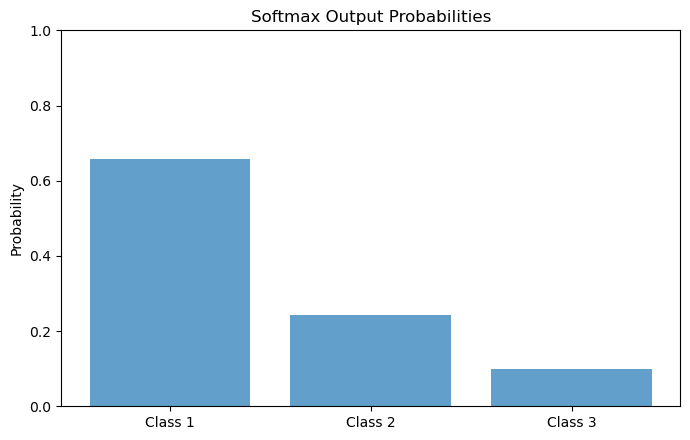

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Example logits for three classes
logits = np.array([2.0, 1.0, 0.1])

# Numerically stable softmax
shifted_logits = logits - np.max(logits)
exp_values = np.exp(shifted_logits)
probabilities = exp_values / np.sum(exp_values)

print("Logits:", logits)
print("Softmax probabilities:", probabilities)
print("Sum of probabilities:", probabilities.sum())

# Plot logits and corresponding probabilities
classes = ["Class 1", "Class 2", "Class 3"]

plt.figure(figsize=(7, 4.5))
plt.bar(classes, probabilities, alpha=0.7)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Softmax Output Probabilities")
plt.tight_layout()
plt.savefig(
    "/Figures/softmax_probabilities.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()